In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import os
from scipy.optimize import minimize

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project8-adaptive-portfolio-optimization", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 10*365)

stocks = ["AAPL", "NVDA", "JPM", "KO", "XOM", "MC.PA", "AMZN", "GC=F", "TLT", "JNJ", "^GSPC", "^IRX"]

df = yf.download(stocks, start= start_date, end = end_date)['Close'].dropna()
assets = df[["AAPL", "NVDA", "JPM", "KO", "XOM", "MC.PA", "AMZN", "GC=F", "TLT", "JNJ",]]

[*********************100%***********************]  12 of 12 completed


In [211]:
assetreturns = assets.pct_change().dropna()

In [212]:
covariance = assetreturns.rolling(30).cov()
correlation = assetreturns.rolling(30).corr()

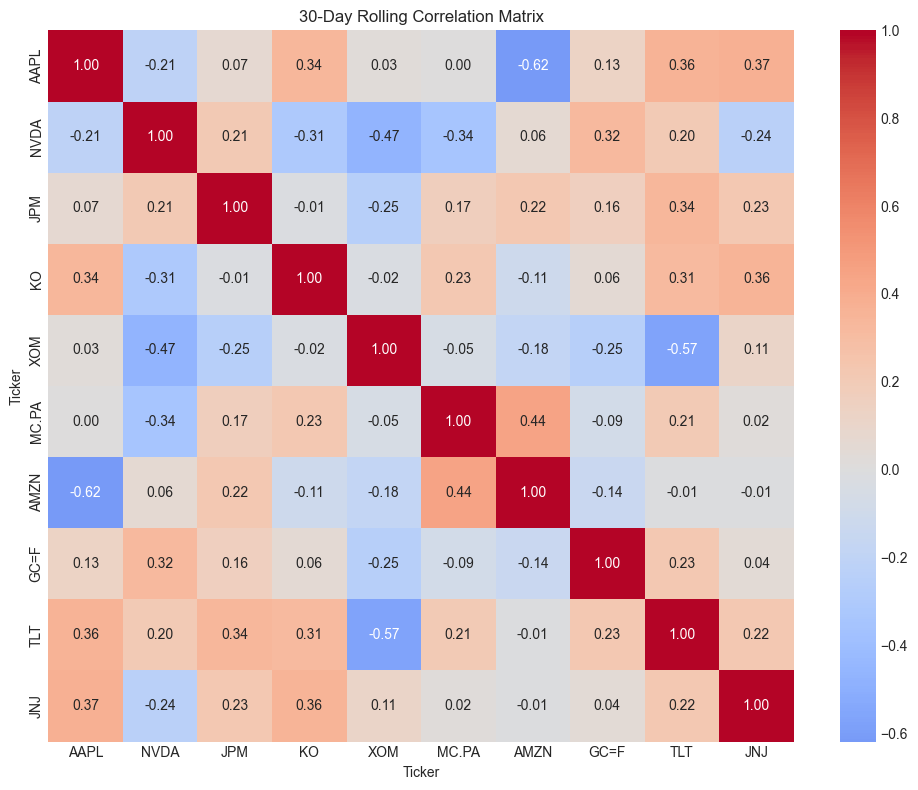

In [213]:
latest_correlation = correlation.loc[correlation.index.get_level_values(0)[-1]]

plt.figure(figsize=(10, 8))
sns.heatmap(latest_correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("30-Day Rolling Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/rolling_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [214]:
weights = np.ones(assets.shape[1])
weights /= assets.shape[1]
r = (1 + df["^IRX"]/100)**(1/252) - 1

In [215]:
def objective_function(weights, window):
    portfolioreturn = weights @ window.T
    portfoliocovariance = window.cov()
    portfoliosharpe = (portfolioreturn.mean() - r.loc[window.index].mean()) / np.sqrt(weights @ portfoliocovariance @ weights)

    return -portfoliosharpe

def volatility_constraint(weights, window, target):
    portfolio_variance = weights @ window.cov() @ weights
    portfolio_volatility = np.sqrt(portfolio_variance) * np.sqrt(252)

    return target - portfolio_volatility

def validate_optimization(result, window, target, bound):
    if not result.success:
        return False

    optimized_weights = result.x

    if not np.isclose(np.sum(optimized_weights), 1):
        print("Weights do not sum to 1")
        return False

    if np.any(optimized_weights < -1e-8):
        print("Negative weight")
        return False

    if np.any(optimized_weights > bound + 1e-5):
        print("Individual weight limit")
        return False

    if optimized_weights[0] + optimized_weights[1] > 0.35 + 1e-8:
        print("Technology constraint")
        return False

    if optimized_weights[2] > 0.25 + 1e-8:
        print("Financial constraint")
        return False

    portfolio_variance = optimized_weights @ window.cov() @ optimized_weights
    portfolio_volatility = np.sqrt(portfolio_variance) * np.sqrt(252)

    if portfolio_volatility > target + 1e-5:
        print("Volatility constraint")
        return False

    return True

In [216]:
def sum_constraint(weights):
    return np.sum(weights) - 1

def technology_constraint(weights):
    return 0.35 - (weights[0] + weights[1])

def financial_constraint(weights):
    return 0.25 - weights[2]

num_weights = len(assetreturns.columns)

In [217]:
initial_weights = np.ones(len(assetreturns.columns))
initial_weights /= len(assetreturns.columns)
def run_backtest(rebalance_frequency, window_size=30, target = 0.20, bound = 0.2, transaction_cost = 0.001):
    rebalancing = assetreturns.copy()
    current_weights = pd.Series(initial_weights, index=assetreturns.columns)
    rebalancing_dates = (rebalancing.groupby(pd.Grouper(freq=rebalance_frequency)).apply(lambda x: x.index[-1]).dropna().values)

    weight_history = []
    turnover_history = []
    transaction_cost_history = []
    daily_returns = []

    for i in range(len(rebalancing)):

        date = rebalancing.index[i]
        current_returns = rebalancing.iloc[i]

        portfolio_return = current_weights @ current_returns
        daily_returns.append(portfolio_return)

        current_weights = current_weights * (1 + current_returns)
        current_weights = current_weights / current_weights.sum()  
 

        if date in rebalancing_dates:
            window = assetreturns.loc[:date].tail(window_size)
            constraints = [
                {'type': 'eq', 'fun': sum_constraint},
                {'type': 'ineq', 'fun': technology_constraint},
                {'type': 'ineq', 'fun': financial_constraint},
                {'type': 'ineq', 'fun': lambda weights: volatility_constraint(weights, window, target)}
            ]

            bounds = [(0, bound) for _ in range(num_weights)]

            opt_weights = np.asarray(current_weights).flatten()

            result = minimize(objective_function, opt_weights, args = (window,), method='SLSQP', bounds=bounds, constraints=constraints)

            if not result.success:
                print(
                    f"{date}: SLSQP failed - {result.message}"
                    f"(volatility target = {target:.0%}, max weight = {bound:.0%}); "
                    f"portfolio kept at previous weights"
                )

            elif not validate_optimization(result, window, target, bound):
                print(
                    f"{date}: SLSQP succeeded but validation failed "
                    f"(volatility target = {target:.0%}, max weight = {bound:.0%})"
                )

            else:
                new_weights = result.x

                turnover = 0.5 * np.sum(abs(new_weights - opt_weights))
                transaction_cost_amount = turnover * transaction_cost

                daily_returns[-1] -= transaction_cost_amount

                turnover_history.append(turnover)
                transaction_cost_history.append(transaction_cost_amount)

                current_weights = pd.Series(new_weights, index=assetreturns.columns)

        weight_history.append(current_weights.tolist())
            

    weight_history = pd.DataFrame(
        weight_history,
        index=rebalancing.index,
        columns=assetreturns.columns
        )

    return (
    pd.Series(
        daily_returns,
        index=rebalancing.index,
        name=f"{rebalance_frequency} Rebalanced Portfolio"
    ),
    weight_history,
    turnover_history,
    transaction_cost_history
)

In [218]:
monthly_returns, monthly_weights, monthly_turnover, monthly_transaction_cost_history = run_backtest("ME")
monthly_wealth = (1 + monthly_returns).cumprod()
monthly_cagr = monthly_wealth.iloc[-1]**(1/10) - 1
monthly_volatility = monthly_returns.std() * np.sqrt(252)

monthly_peaks = monthly_wealth.cummax()
monthly_drawdowns = (monthly_wealth - monthly_peaks) / monthly_peaks
monthly_maximum_drawdown = monthly_drawdowns.min()

monthly_calmar = monthly_cagr / abs(monthly_maximum_drawdown)

monthly_excess = monthly_returns - r.loc[monthly_returns.index]
monthly_downside_risk = np.sqrt(np.mean(np.minimum(monthly_excess, 0)**2)) * np.sqrt(252)

monthly_average_turnover = np.mean(monthly_turnover)

2020-03-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-04-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights


In [219]:
quarterly_returns, quarterly_weights, quarterly_turnover, quarterly_transaction_cost_history = run_backtest("QE")
quarterly_wealth = (1 + quarterly_returns).cumprod()
quarterly_cagr = quarterly_wealth.iloc[-1]**(1/10) - 1
quarterly_volatility = quarterly_returns.std() * np.sqrt(252)

quarterly_peaks = quarterly_wealth.cummax()
quarterly_drawdowns = (quarterly_wealth - quarterly_peaks) / quarterly_peaks
quarterly_maximum_drawdown = quarterly_drawdowns.min()

quarterly_calmar = quarterly_cagr / abs(quarterly_maximum_drawdown)

quarterly_excess = quarterly_returns - r.loc[quarterly_returns.index]
quarterly_downside_risk = np.sqrt(np.mean(np.minimum(quarterly_excess, 0)**2)) * np.sqrt(252)

quarterly_average_turnover = np.mean(quarterly_turnover)

2020-03-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights


In [220]:
equal_weights = np.ones(assets.shape[1])
equal_weights /= assets.shape[1]
static_returns = assetreturns @ equal_weights

In [221]:
def rolling_sharpe(returns):
    excess = returns - r.loc[returns.index]
    return excess.rolling(30).mean().div(excess.rolling(30).std()).mul(np.sqrt(252))

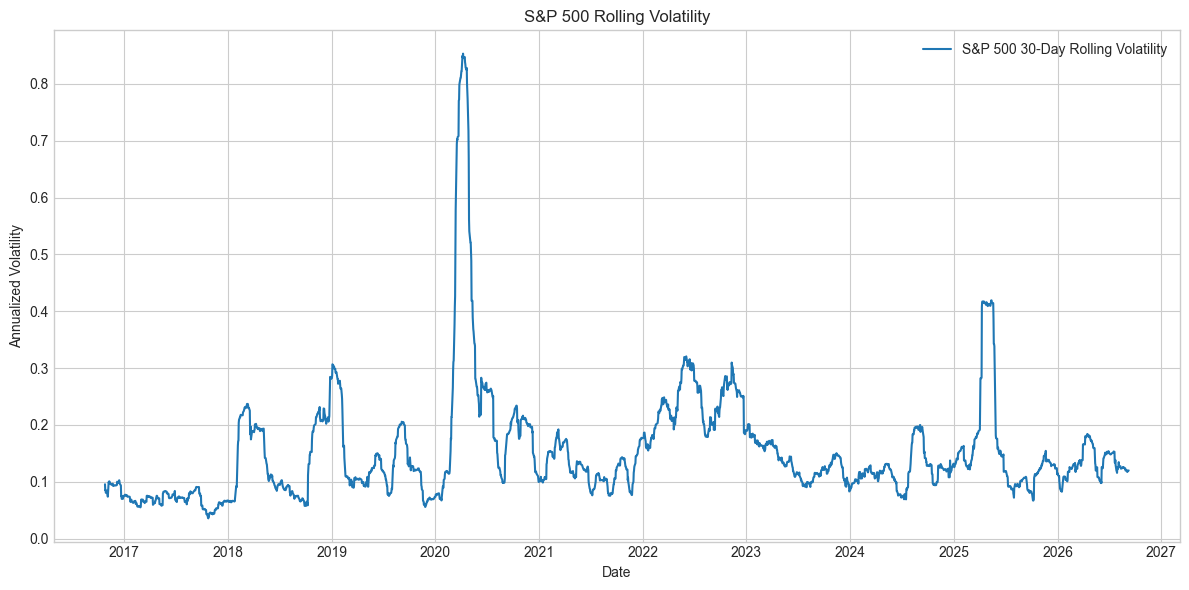

In [222]:
benchmark = df["^GSPC"].pct_change().dropna()
benchmarkvolatility = benchmark.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))

plt.plot(benchmarkvolatility, label="S&P 500 30-Day Rolling Volatility")

plt.title("S&P 500 Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()

plt.tight_layout()
plt.savefig(
    "project8-adaptive-portfolio-optimization/sp500_rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [223]:
low_threshold = benchmarkvolatility.quantile(0.33)
high_threshold = benchmarkvolatility.quantile(0.67)

regime = pd.Series(
    np.where(benchmarkvolatility <= low_threshold, "Low", np.where(benchmarkvolatility >= high_threshold,"High","Normal")),
    index=benchmarkvolatility.index)

In [224]:
regime.value_counts(normalize=True) * 100

Normal    34.756343
Low       32.621828
High      32.621828
Name: proportion, dtype: float64

In [225]:
monthly_regime = regime.loc[monthly_returns.index]
print(monthly_returns.groupby(monthly_regime).mean())
print(monthly_returns.groupby(monthly_regime).std() * np.sqrt(252))

High      0.000694
Low       0.000835
Normal    0.000879
Name: ME Rebalanced Portfolio, dtype: float64
High      0.175406
Low       0.086581
Normal    0.114818
Name: ME Rebalanced Portfolio, dtype: float64


In [226]:
quarterly_regime = regime.loc[quarterly_returns.index]
print(quarterly_returns.groupby(quarterly_regime).mean())
print(quarterly_returns.groupby(quarterly_regime).std() * np.sqrt(252))

High      0.000223
Low       0.000912
Normal    0.000735
Name: QE Rebalanced Portfolio, dtype: float64
High      0.179438
Low       0.094427
Normal    0.119977
Name: QE Rebalanced Portfolio, dtype: float64


In [227]:
low_returns = assetreturns.loc[regime == "Low"]
normal_returns = assetreturns.loc[regime == "Normal"]
high_returns = assetreturns.loc[regime == "High"]
low_correlation = low_returns.corr()
normal_correlation = normal_returns.corr()
high_correlation = high_returns.corr()

In [228]:
monthly_weights_regime = monthly_weights.copy()
monthly_weights_regime["Regime"] = monthly_regime
monthly_average_weights = monthly_weights_regime.groupby("Regime").mean()
monthly_average_weights

Ticker,AAPL,NVDA,JPM,KO,XOM,MC.PA,AMZN,GC=F,TLT,JNJ
Regime,,,,,,,,,,
High,0.063719,0.060591,0.086806,0.144364,0.080349,0.090967,0.070915,0.150112,0.134872,0.117306
Low,0.105839,0.065746,0.126270,0.104205,0.075990,0.088052,0.053679,0.114856,0.147884,0.117480
Normal,0.089915,0.079933,0.121734,0.114975,0.097448,0.064914,0.076411,0.144709,0.105331,0.104630


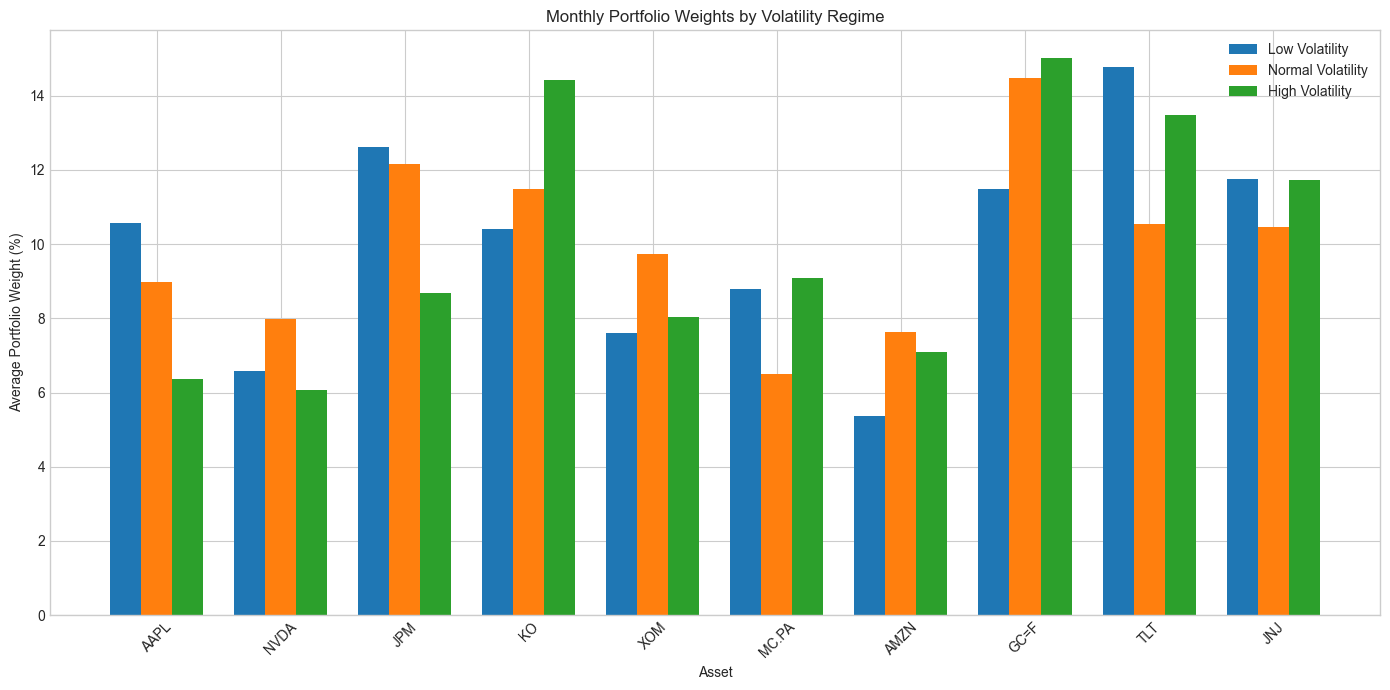

In [229]:
plt.figure(figsize=(14, 7))

x = np.arange(len(monthly_average_weights.columns))
width = 0.25

plt.bar(
    x - width,
    monthly_average_weights.loc["Low"] * 100,
    width,
    label="Low Volatility"
)

plt.bar(
    x,
    monthly_average_weights.loc["Normal"] * 100,
    width,
    label="Normal Volatility"
)

plt.bar(
    x + width,
    monthly_average_weights.loc["High"] * 100,
    width,
    label="High Volatility"
)

plt.xticks(
    x,
    monthly_average_weights.columns,
    rotation=45
)

plt.xlabel("Asset")
plt.ylabel("Average Portfolio Weight (%)")
plt.title("Monthly Portfolio Weights by Volatility Regime")
plt.legend()

plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/monthly_weights_by_regime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [230]:
weight_response = (
    monthly_weights_regime
    .groupby("Regime")
    .mean()
    .T
)

weight_response["High_vs_Low"] = (
    weight_response["High"] -
    weight_response["Low"]
)
weight_response

Regime,High,Low,Normal,High_vs_Low
Ticker,,,,
AAPL,0.063719,0.105839,0.089915,-0.042120
NVDA,0.060591,0.065746,0.079933,-0.005155
JPM,0.086806,0.126270,0.121734,-0.039464
KO,0.144364,0.104205,0.114975,0.040159
XOM,0.080349,0.075990,0.097448,0.004359
MC.PA,0.090967,0.088052,0.064914,0.002915
AMZN,0.070915,0.053679,0.076411,0.017236
GC=F,0.150112,0.114856,0.144709,0.035256
TLT,0.134872,0.147884,0.105331,-0.013012


In [231]:
quarterly_weights_regime = quarterly_weights.copy()
quarterly_weights_regime["Regime"] = quarterly_regime
quarterly_average_weights = quarterly_weights_regime.groupby("Regime").mean()
weight_response = (
    quarterly_weights_regime
    .groupby("Regime")
    .mean()
    .T
)

weight_response["High_vs_Low"] = (
    weight_response["High"] -
    weight_response["Low"]
)
weight_response

Regime,High,Low,Normal,High_vs_Low
Ticker,,,,
AAPL,0.068554,0.090336,0.096867,-0.021782
NVDA,0.036287,0.069243,0.068402,-0.032956
JPM,0.071519,0.109235,0.113757,-0.037716
KO,0.155814,0.094604,0.114134,0.061209
XOM,0.077237,0.089658,0.092744,-0.012421
MC.PA,0.078528,0.100150,0.089952,-0.021623
AMZN,0.067964,0.073902,0.054890,-0.005938
GC=F,0.156160,0.120388,0.133787,0.035772
TLT,0.134589,0.152576,0.126896,-0.017987


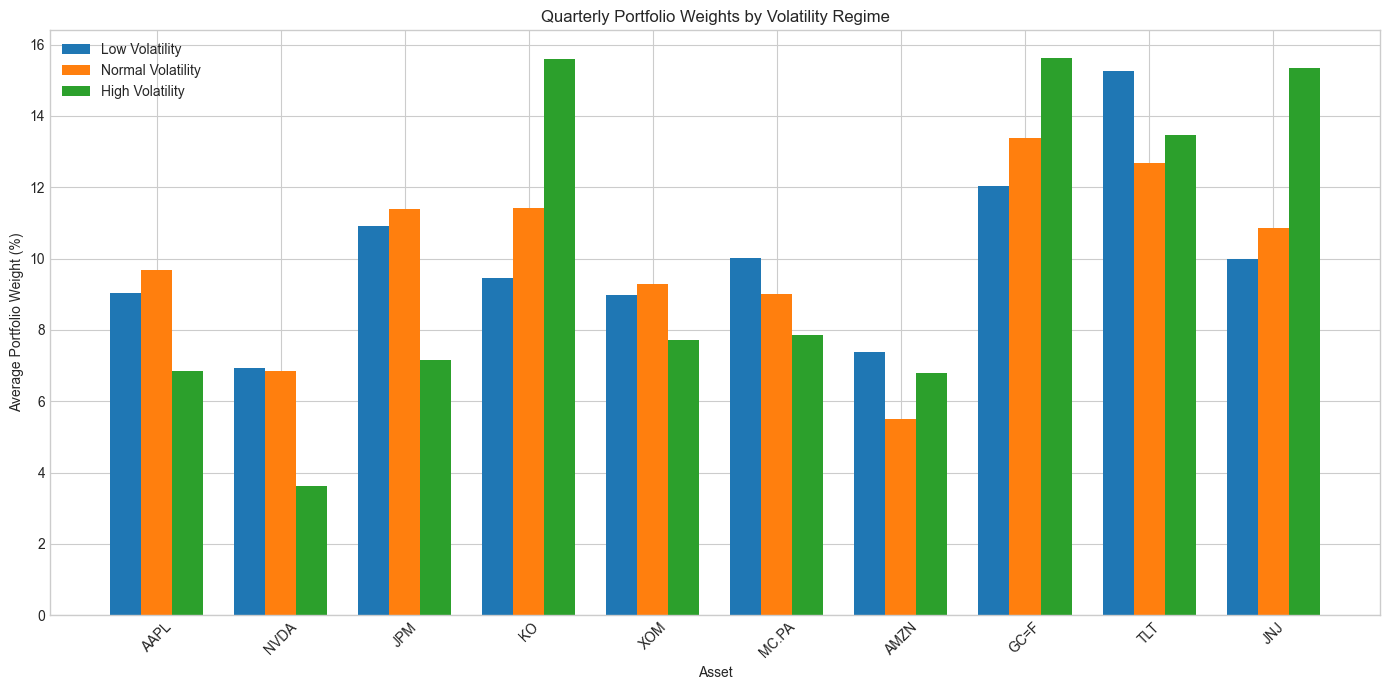

In [232]:
plt.figure(figsize=(14, 7))

x = np.arange(len(quarterly_average_weights.columns))
width = 0.25

plt.bar(
    x - width,
    quarterly_average_weights.loc["Low"] * 100,
    width,
    label="Low Volatility"
)

plt.bar(
    x,
    quarterly_average_weights.loc["Normal"] * 100,
    width,
    label="Normal Volatility"
)

plt.bar(
    x + width,
    quarterly_average_weights.loc["High"] * 100,
    width,
    label="High Volatility"
)

plt.xticks(
    x,
    quarterly_average_weights.columns,
    rotation=45
)

plt.xlabel("Asset")
plt.ylabel("Average Portfolio Weight (%)")
plt.title("Quarterly Portfolio Weights by Volatility Regime")
plt.legend()

plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/quarterly_weights_by_regime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [233]:
results = {
    (target, bound): run_backtest("ME",window_size=30,target=target,bound=bound)
    for target in [0.15, 0.20, 0.25]
    for bound in [0.15, 0.20, 0.25]
}

2020-03-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 15%, max weight = 15%); portfolio kept at previous weights
2020-04-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 15%, max weight = 15%); portfolio kept at previous weights
2022-05-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 15%, max weight = 15%); portfolio kept at previous weights
2022-06-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 15%, max weight = 15%); portfolio kept at previous weights
2022-10-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 15%, max weight = 15%); portfolio kept at previous weights
2025-04-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 15%, max weight = 15%); portfolio kept at previous weights
2020-03-31 00:00:00: SLSQP f

In [234]:
transactionresults = {transaction_cost: run_backtest("ME", transaction_cost=transaction_cost) for transaction_cost in [0.0001, 0.0005, 0.001, 0.002, 0.005]}

2020-03-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-04-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-03-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-04-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-03-31 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-04-30 00:00:00: SLSQP failed - Positive directional derivative for linesearch(volatility target = 20%, max weight = 20%); portfolio kept at previous weights
2020-03-31 00:00:00: SLSQP f

In [235]:
transaction_metrics = {}
for transaction_cost, result in transactionresults.items():
    returns, weights, turnover, costs = result
    wealth = (1 + returns).cumprod()
    cagr = wealth.iloc[-1]**(1/10) - 1
    volatility = returns.std() * np.sqrt(252)

    excess_returns = returns - r.loc[returns.index]
    sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(252) 
    
    drawdown = ((wealth - wealth.cummax()) / wealth.cummax()).min()

    transaction_metrics[transaction_cost] = {
            "CAGR": cagr,
            "Volatility": volatility,
            "Sharpe": sharpe,
            "Maximum Drawdown": drawdown,
            "Total Transaction Costs": np.sum(costs)
        }

transaction_table = pd.DataFrame(transaction_metrics).T
transaction_table.index.name = "Transaction Cost"
transaction_table

,CAGR,Volatility,Sharpe,Maximum Drawdown,Total Transaction Costs
Transaction Cost,,,,,
0.0001,0.215236,0.130546,1.401836,-0.169290,0.004136
0.0005,0.213226,0.130561,1.388812,-0.169402,0.020682
0.0010,0.210718,0.130583,1.372508,-0.169542,0.041363
0.0020,0.205716,0.130635,1.339823,-0.169821,0.082726
0.0050,0.190822,0.130865,1.241242,-0.175136,0.206816


In [236]:
robustness_metrics = {}

for (target, bound), result in results.items():
    returns, weights_result, turnover, costs = result

    wealth = (1 + returns).cumprod()
    cagr = wealth.iloc[-1]**(1/10) - 1
    volatility = returns.std() * np.sqrt(252)
    sharpe = ((returns - r.loc[returns.index]).mean() /
              (returns - r.loc[returns.index]).std()) * np.sqrt(252)
    drawdown = ((wealth - wealth.cummax()) / wealth.cummax()).min()

    robustness_metrics[(target, bound)] = {
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Maximum Drawdown": drawdown
    }

robustness_table = pd.DataFrame(robustness_metrics).T
robustness_table.index.names = ["Volatility Target", "Max Weight"]

robustness_table

CAGR  Volatility    Sharpe  Maximum Drawdown
Volatility Target Max Weight                                                  
0.15              0.15        0.212395    0.127757  1.411051         -0.189184
                  0.20        0.210304    0.126623  1.408665         -0.169773
                  0.25        0.201248    0.127929  1.335828         -0.150967
0.20              0.15        0.217309    0.132772  1.393599         -0.189134
                  0.20        0.210718    0.130583  1.372508         -0.169542
                  0.25        0.207383    0.132803  1.330520         -0.167367
0.25              0.15        0.216109    0.132874  1.385087         -0.189134
                  0.20        0.213261    0.131313  1.381814         -0.169542
                  0.25        0.202060    0.133371  1.291797         -0.167367

In [237]:
rebalancing_metrics = {}

for name, returns, turnover, costs in [
    ("Monthly", monthly_returns, monthly_turnover, monthly_transaction_cost_history),
    ("Quarterly", quarterly_returns, quarterly_turnover, quarterly_transaction_cost_history)
]:
    wealth = (1 + returns).cumprod()

    cagr = wealth.iloc[-1]**(1/10) - 1
    volatility = returns.std() * np.sqrt(252)

    excess_returns = returns - r.loc[returns.index]
    sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(252)

    drawdown = ((wealth - wealth.cummax()) / wealth.cummax()).min()
    calmar = cagr / abs(drawdown)

    rebalancing_metrics[name] = {
        "Final Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Maximum Drawdown": drawdown,
        "Calmar": calmar,
        "Average Turnover": np.mean(turnover),
        "Transaction Costs": np.sum(costs)
    }

rebalancing_table = pd.DataFrame(rebalancing_metrics).T

rebalancing_table

,Final Wealth,CAGR,Volatility,Sharpe,Maximum Drawdown,Calmar,Average Turnover,Transaction Costs
Monthly,6.767540,0.210718,0.130583,1.372508,-0.169542,1.242869,0.347590,0.041363
Quarterly,4.317101,0.157495,0.135726,0.989099,-0.229588,0.685991,0.469679,0.018787


In [238]:
equal_weights.shape

(10,)

In [239]:
initial_window = assetreturns.iloc[:30]

constraints = [
    {'type': 'eq', 'fun': sum_constraint},
    {'type': 'ineq', 'fun': technology_constraint},
    {'type': 'ineq', 'fun': financial_constraint},
    {'type': 'ineq', 'fun': lambda weights: volatility_constraint(weights, initial_window, 0.20)}
]

bounds = [(0, 0.20) for _ in range(num_weights)]

initial_result = minimize(
    objective_function,
    equal_weights,
    args=(initial_window,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000}
)

static_optimized_weights = initial_result.x

In [240]:
static_optimized_returns = assetreturns.iloc[30:] @ static_optimized_weights
strategy_results = {
    "S&P 500": df["^GSPC"].pct_change().dropna(),
    "Equal Weight": static_returns,
    "Static Optimized": static_optimized_returns,
    "Adaptive Monthly": monthly_returns,
    "Adaptive Quarterly": quarterly_returns
}

strategy_metrics = {}

for name, returns in strategy_results.items():

    wealth = (1 + returns).cumprod()

    years = (returns.index[-1] - returns.index[0]).days / 365.25
    cagr = wealth.iloc[-1]**(1/years) - 1

    volatility = returns.std() * np.sqrt(252)

    excess_returns = returns - r.loc[returns.index]
    sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(252)

    drawdown = (wealth - wealth.cummax()) / wealth.cummax()
    maximum_drawdown = drawdown.min()

    calmar = cagr / abs(maximum_drawdown)

    strategy_metrics[name] = {
        "Final Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Maximum Drawdown": maximum_drawdown,
        "Calmar": calmar
    }

strategy_table = pd.DataFrame(strategy_metrics).T

strategy_table["Average Turnover"] = np.nan
strategy_table["Transaction Costs"] = np.nan

strategy_table.loc["Adaptive Monthly", "Average Turnover"] = np.mean(monthly_turnover)
strategy_table.loc["Adaptive Monthly", "Transaction Costs"] = np.sum(monthly_transaction_cost_history)

strategy_table.loc["Adaptive Quarterly", "Average Turnover"] = np.mean(quarterly_turnover)
strategy_table.loc["Adaptive Quarterly", "Transaction Costs"] = np.sum(quarterly_transaction_cost_history)

strategy_table

,Final Wealth,CAGR,Volatility,Sharpe,Maximum Drawdown,Calmar,Average Turnover,Transaction Costs
S&P 500,3.554135,0.135420,0.181343,0.671597,-0.339250,0.399174,NaN,NaN
Equal Weight,7.116568,0.217182,0.148651,1.257074,-0.249850,0.869252,NaN,NaN
Static Optimized,8.690483,0.244996,0.198807,1.097957,-0.325825,0.751926,NaN,NaN
Adaptive Monthly,6.767540,0.211067,0.130583,1.372508,-0.169542,1.244929,0.347590,0.041363
Adaptive Quarterly,4.317101,0.157751,0.135726,0.989099,-0.229588,0.687103,0.469679,0.018787


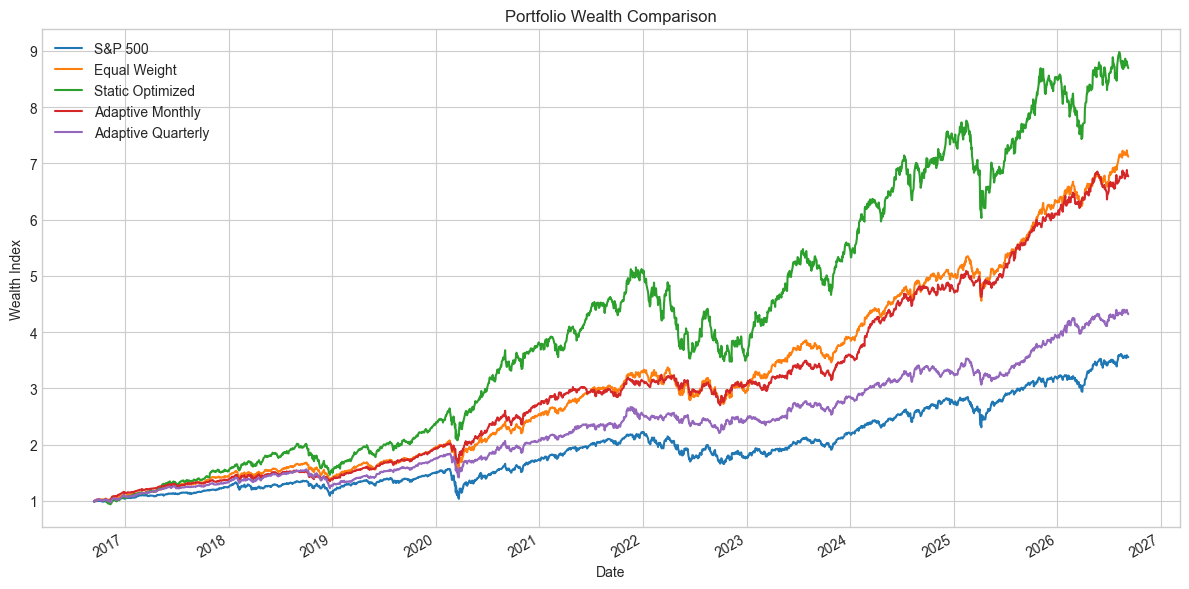

In [241]:
strategy_wealth = {}

for name, returns in strategy_results.items():
    strategy_wealth[name] = (1 + returns).cumprod()

strategy_wealth = pd.DataFrame(strategy_wealth)

strategy_wealth.plot(figsize=(12, 6))

plt.title("Portfolio Wealth Comparison")
plt.xlabel("Date")
plt.ylabel("Wealth Index")

plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/wealth_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

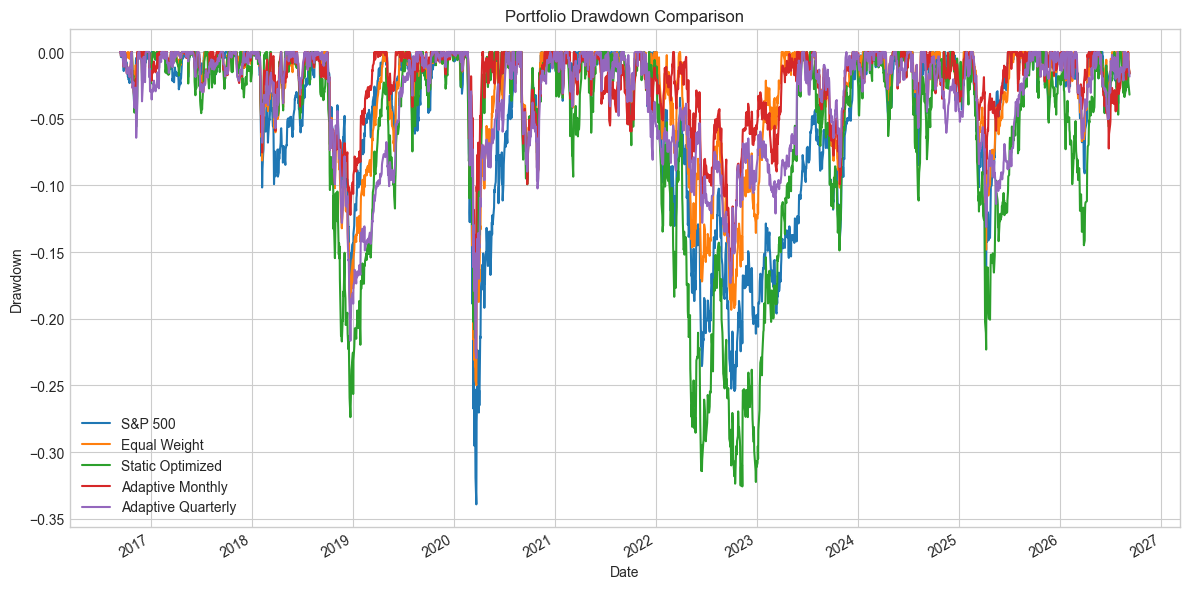

In [242]:
strategy_drawdowns = {}

for name, wealth in strategy_wealth.items():
    strategy_drawdowns[name] = (wealth - wealth.cummax()) / wealth.cummax()

strategy_drawdowns = pd.DataFrame(strategy_drawdowns)

strategy_drawdowns.plot(figsize=(12, 6))

plt.title("Portfolio Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/drawdown_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

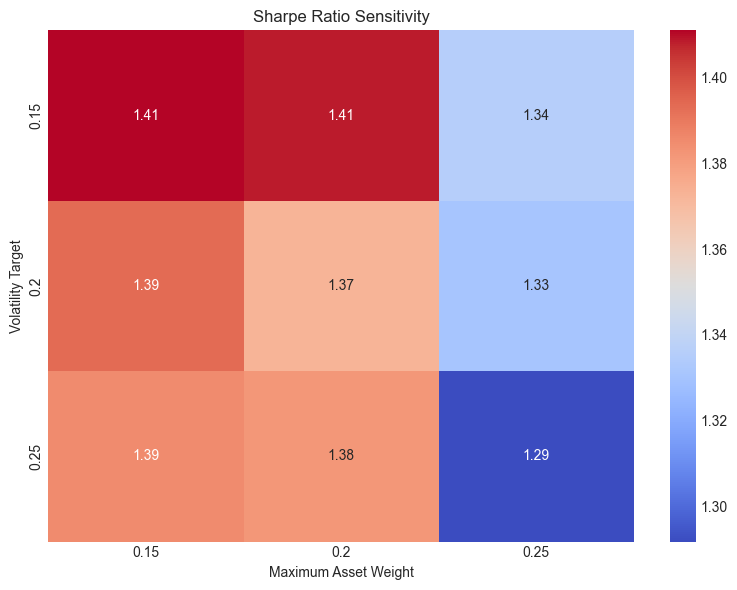

In [243]:
robustness_sharpe = robustness_table["Sharpe"].unstack()

plt.figure(figsize=(8, 6))

sns.heatmap(
    robustness_sharpe,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Sharpe Ratio Sensitivity")
plt.xlabel("Maximum Asset Weight")
plt.ylabel("Volatility Target")

plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/robustness_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

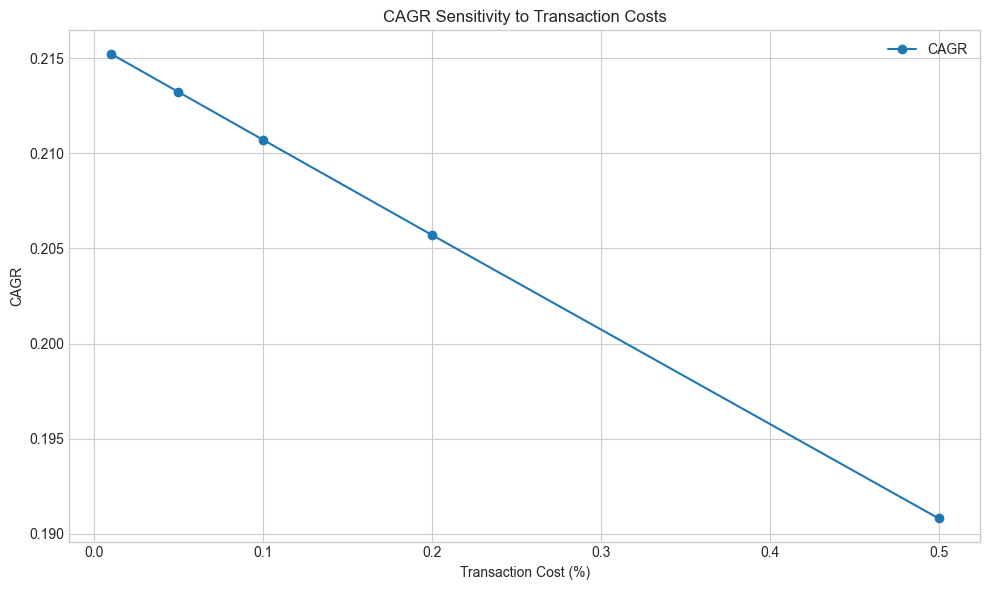

In [244]:
transaction_table_plot = transaction_table.copy()
transaction_table_plot.index = transaction_table_plot.index * 100
transaction_table_plot.plot(
    y="CAGR",
    marker="o",
    figsize=(10, 6)
)

plt.title("CAGR Sensitivity to Transaction Costs")
plt.xlabel("Transaction Cost (%)")
plt.ylabel("CAGR")

plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/transaction_cost_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

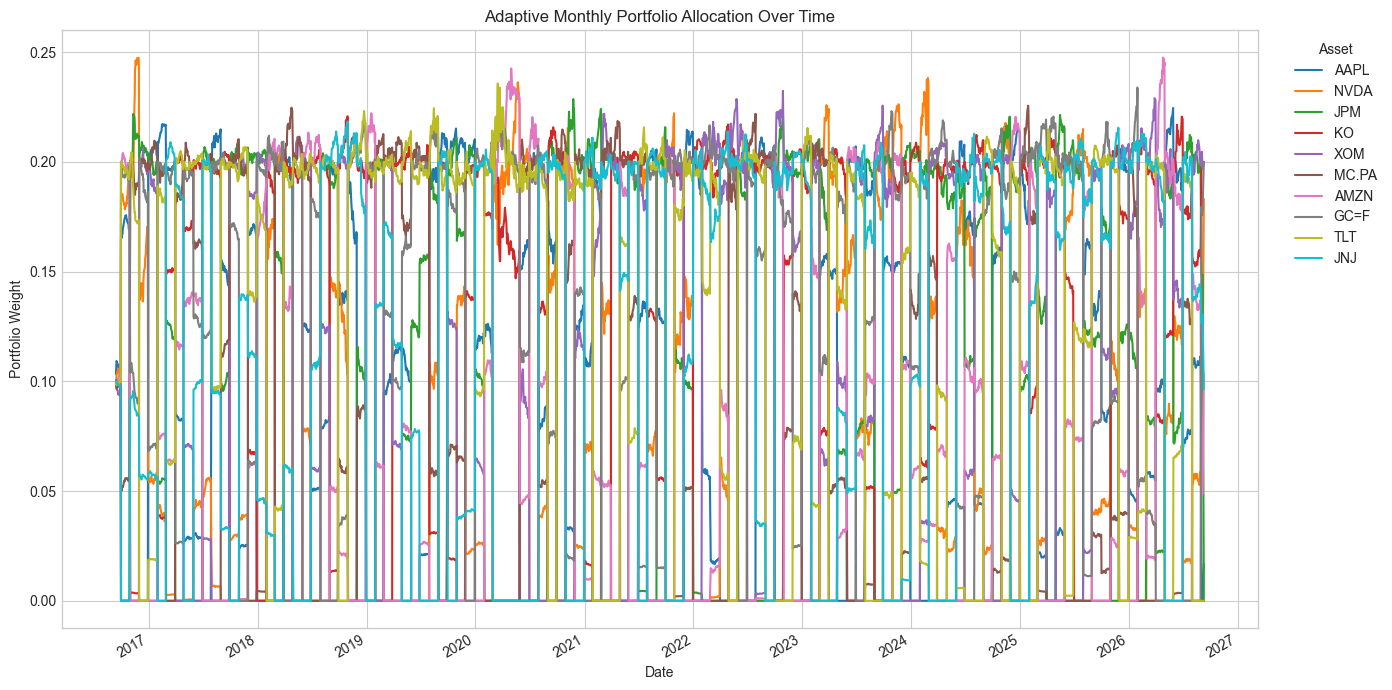

In [245]:
monthly_weights.plot(figsize=(14, 7), linewidth=1.5)

plt.title("Adaptive Monthly Portfolio Allocation Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left"
)
plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/monthly_adaptive_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

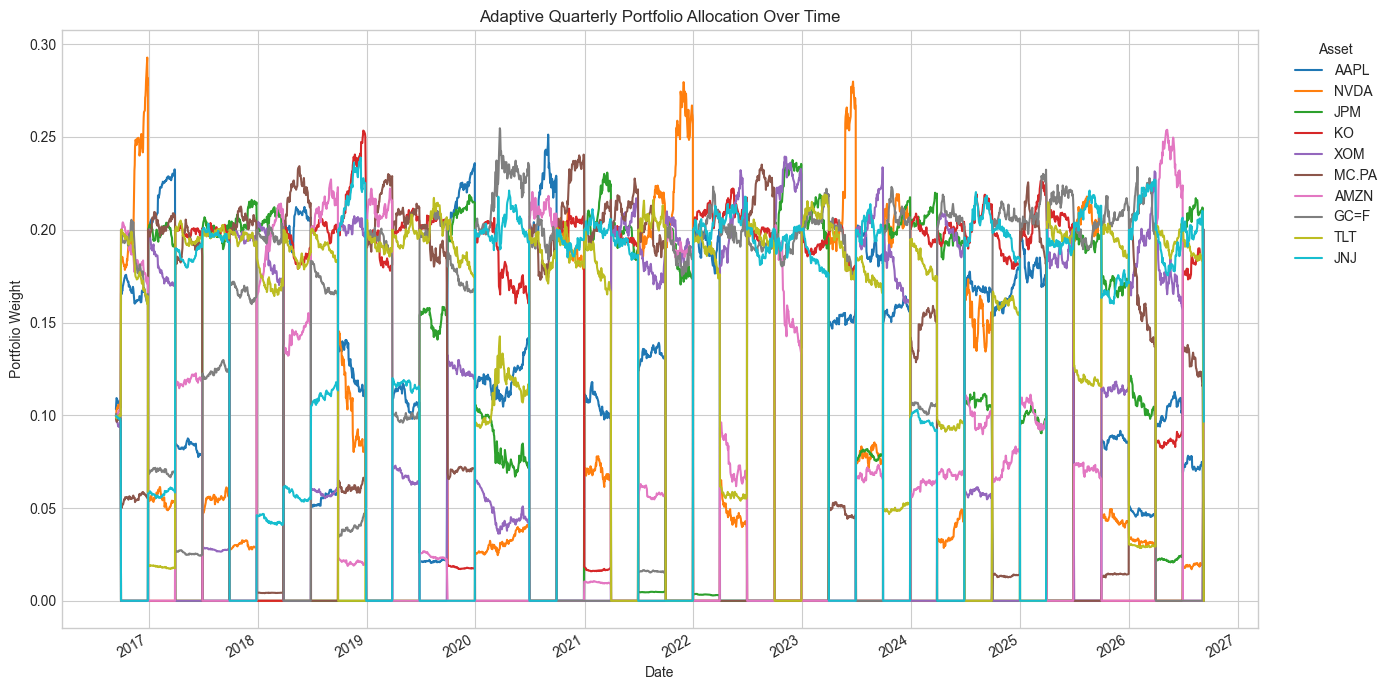

In [246]:
quarterly_weights.plot(figsize=(14, 7), linewidth=1.5)

plt.title("Adaptive Quarterly Portfolio Allocation Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left"
)
plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/quarterly_adaptive_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [247]:
nan_rows = quarterly_weights[quarterly_weights.isna().any(axis=1)]

print(nan_rows.index)
print(nan_rows)

DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)
Empty DataFrame
Columns: [AAPL, NVDA, JPM, KO, XOM, MC.PA, AMZN, GC=F, TLT, JNJ]
Index: []


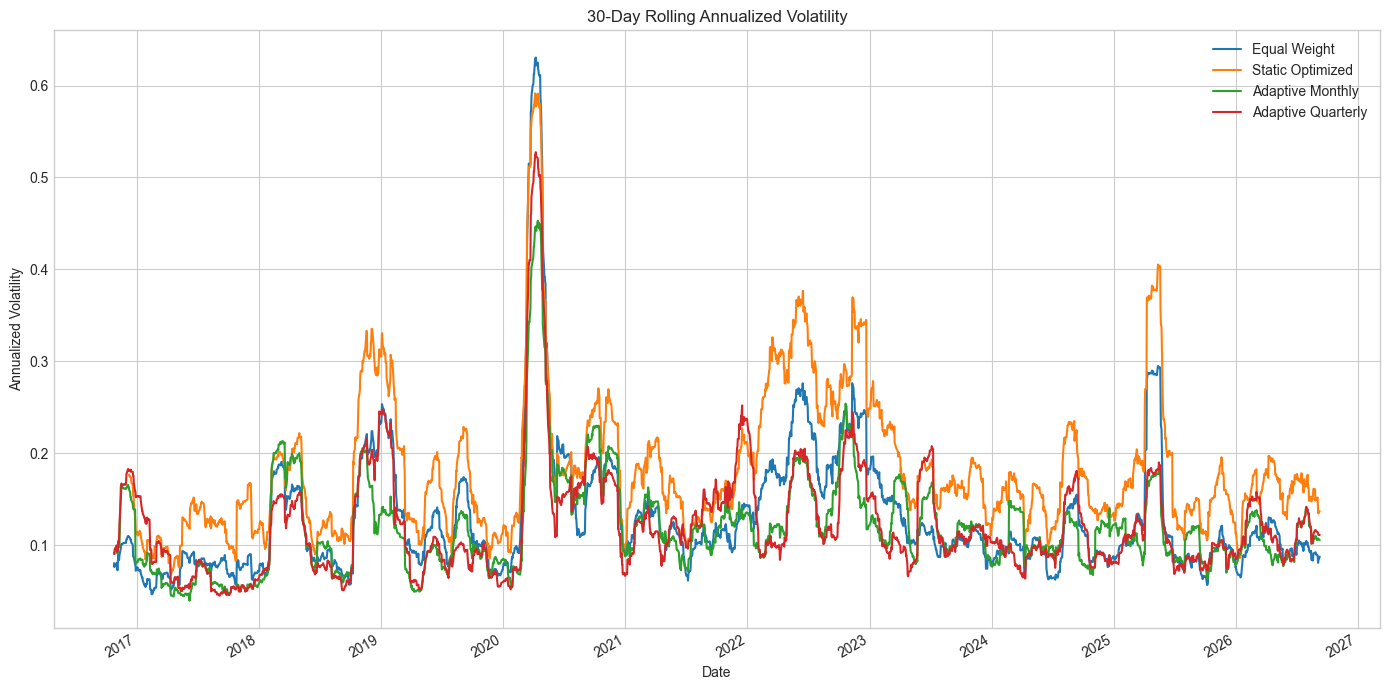

In [248]:
rolling_volatility_comparison = pd.DataFrame({
    "Equal Weight": static_returns.rolling(30).std() * np.sqrt(252),
    "Static Optimized": static_optimized_returns.rolling(30).std() * np.sqrt(252),
    "Adaptive Monthly": monthly_returns.rolling(30).std() * np.sqrt(252),
    "Adaptive Quarterly": quarterly_returns.rolling(30).std() * np.sqrt(252)
})

rolling_volatility_comparison.plot(figsize=(14, 7))

plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/rolling_volatility_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

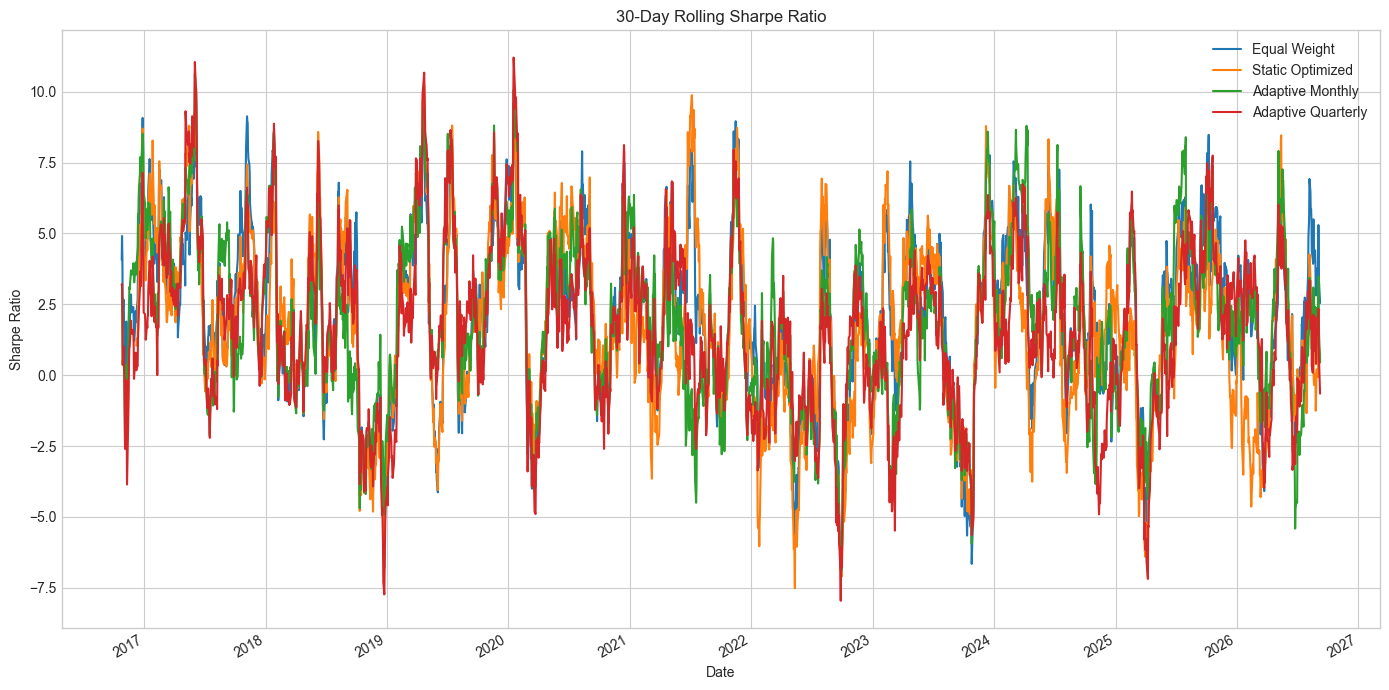

In [249]:
rolling_sharpe_comparison = pd.DataFrame({
    "Equal Weight": ((static_returns - r.loc[static_returns.index]).rolling(30).mean() /
                     (static_returns - r.loc[static_returns.index]).rolling(30).std()) * np.sqrt(252),

    "Static Optimized": ((static_optimized_returns - r.loc[static_optimized_returns.index]).rolling(30).mean() /
                         (static_optimized_returns - r.loc[static_optimized_returns.index]).rolling(30).std()) * np.sqrt(252),

    "Adaptive Monthly": ((monthly_returns - r.loc[monthly_returns.index]).rolling(30).mean() /
                         (monthly_returns - r.loc[monthly_returns.index]).rolling(30).std()) * np.sqrt(252),

    "Adaptive Quarterly": ((quarterly_returns - r.loc[quarterly_returns.index]).rolling(30).mean() /
                           (quarterly_returns - r.loc[quarterly_returns.index]).rolling(30).std()) * np.sqrt(252)
})

rolling_sharpe_comparison.plot(figsize=(14, 7))

plt.title("30-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()

plt.savefig(
    "project8-adaptive-portfolio-optimization/rolling_sharpe_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()